# Why CrossEntropyLoss takes logits, and four other whiteboard derivations

Companion notebook for the article. Run all cells to reproduce every number and the figure. Needs only NumPy and matplotlib.

From [*Math for ML Engineers: From Backprop to RLHF*](https://mikaelyemane.github.io/ml-math-code/) by Mikael Yemane.

## 1. Where does cross-entropy come from, and what is its gradient?

In [1]:
import numpy as np

z, y = np.array([2.0, -1.0, 0.5]), np.array([0.0, 0.0, 1.0])
ce = lambda z: -(y * (z - np.log(np.exp(z).sum()))).sum()
p = np.exp(z) / np.exp(z).sum()
fd = np.array([(ce(z + h) - ce(z - h)) / 2e-6 for h in np.eye(3) * 1e-6])
print(p - y, fd)   # the two vectors agree to about 1e-10

rng, V = np.random.default_rng(0), 1000
zv, yv = rng.standard_normal(V), np.eye(V)[0]
pv = np.exp(zv) / np.exp(zv).sum()               # the model's own softmax
qv = np.exp(pv) / np.exp(pv).sum()               # CrossEntropyLoss applies another
g_bad = pv * ((qv - yv) - pv @ (qv - yv))        # gradient reaching the logits
g_ok = pv - yv
print(f"max |grad| correct {np.abs(g_ok).max():.4f}, double softmax {np.abs(g_bad).max():.1e}, "
      f"ratio {np.abs(g_ok).max() / np.abs(g_bad).max():,.0f}")
print(f"loss floor {np.log(1 + (V - 1) / np.e):.2f} nats, ln V = {np.log(V):.2f}")

[ 0.78559703  0.03911257 -0.82470961] [ 0.78559703  0.03911257 -0.82470961]
max |grad| correct 0.9993, double softmax 7.4e-04, ratio 1,345
loss floor 5.91 nats, ln V = 6.91


## 3. Why does AdamW decouple weight decay?

In [2]:
import numpy as np

rng = np.random.default_rng(0)
eta, lam, b1, b2, eps = 1e-3, 0.1, 0.9, 0.999, 1e-8
sigma = np.array([0.01, 1.0])                # gradient noise scale per coordinate
for mode in ("L2 inside Adam", "AdamW"):
    th, m, v = np.ones(2), np.zeros(2), np.zeros(2)
    for t in range(1, 2001):
        g = sigma * rng.standard_normal(2)   # zero-mean loss gradient
        if mode == "L2 inside Adam":
            g = g + lam * th
        m, v = b1 * m + (1 - b1) * g, b2 * v + (1 - b2) * g**2
        th = th - eta * (m / (1 - b1**t)) / (np.sqrt(v / (1 - b2**t)) + eps)
        if mode == "AdamW":
            th = th - eta * lam * th
    print(f"{mode:15s} theta after 2,000 steps: {np.round(th, 3)}")

L2 inside Adam  theta after 2,000 steps: [0.022 0.824]
AdamW           theta after 2,000 steps: [0.781 0.798]


## The figure

In [3]:
#@title Shared figure style (run this cell; the code can stay hidden)
"""Shared figure style for the article series.

Static PNGs for Medium/Substack (light page), 1600 x 900 px at 200 dpi.
Palette: validated categorical slots 1-3 (all-pairs pass, light mode).
Slot 3 (aqua) is below 3:1 contrast on the surface, so every series is
direct-labeled; identity never rests on color alone.
"""
import matplotlib

import matplotlib.pyplot as plt  # noqa: E402

SURFACE = "#ffffff"
INK = "#0b0b0b"          # primary text
INK_2 = "#52514e"        # secondary text, axis labels
MUTED = "#8a8985"        # tick labels, annotations
GRID = "#e8e7e3"         # recessive grid
NEUTRAL = "#b9b8b3"      # de-emphasized series / reference lines

S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
SERIES = [S1, S2, S3]

FIG_W, FIG_H, DPI = 8.0, 4.5, 200


def setup():
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titlepad": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.labelcolor": INK_2,
    })


def fig(nrows=1, ncols=1, **kw):
    setup()
    return plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H), dpi=DPI, **kw)


def subtitle(ax, text):
    """Units / one-line context under the title, in secondary ink."""
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK_2,
            fontsize=10, va="bottom", ha="left")


def label_end(ax, x, y, text, color, dx=4, dy=0):
    """Direct label at a line's end, in text ink with a color key dot."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                color=INK, fontsize=10, va="center", ha="left")


def save(f, path):
    f.tight_layout()
    f.savefig(path, dpi=DPI)
    print("wrote", path)

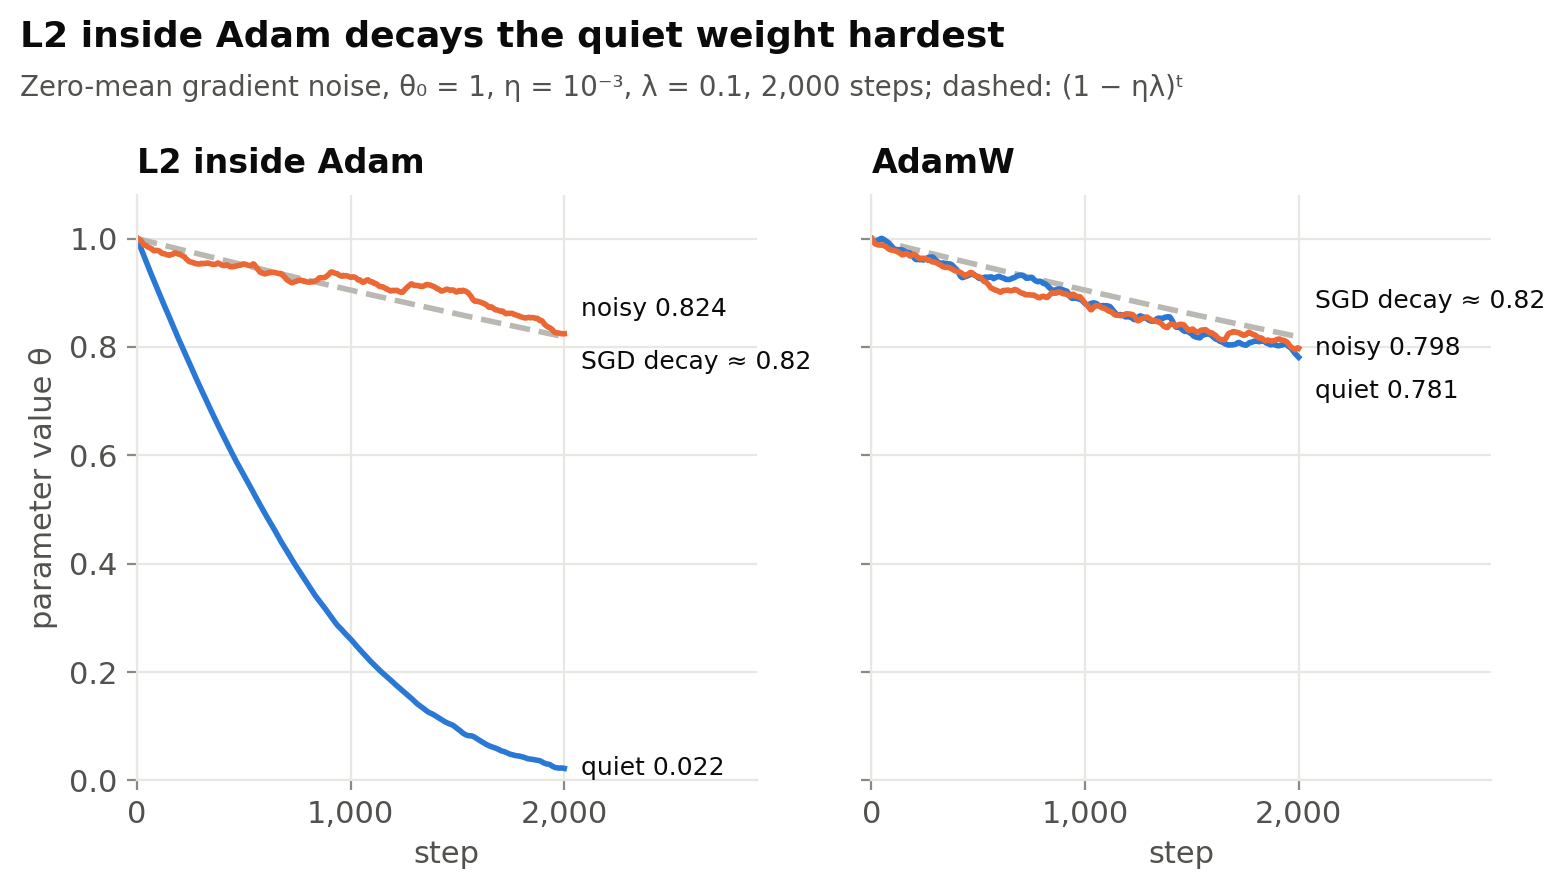

In [4]:
#@title The figure
import contextlib, io
__file__ = 'figure.py'  # the PNG is saved next to the notebook
with contextlib.redirect_stdout(io.StringIO()):  # keep the output to the chart
    import pathlib
    import numpy as np

    # The article's code, unchanged except for recording the trajectory.
    rng = np.random.default_rng(0)
    eta, lam, b1, b2, eps = 1e-3, 0.1, 0.9, 0.999, 1e-8
    sigma = np.array([0.01, 1.0])
    T = 2000
    traj = {}
    for mode in ("L2 inside Adam", "AdamW"):
        th, m, v = np.ones(2), np.zeros(2), np.zeros(2)
        hist = [th.copy()]
        for t in range(1, T + 1):
            g = sigma * rng.standard_normal(2)
            if mode == "L2 inside Adam":
                g = g + lam * th
            m, v = b1 * m + (1 - b1) * g, b2 * v + (1 - b2) * g**2
            th = th - eta * (m / (1 - b1**t)) / (np.sqrt(v / (1 - b2**t)) + eps)
            if mode == "AdamW":
                th = th - eta * lam * th
            hist.append(th.copy())
        traj[mode] = np.array(hist)
        print(mode, np.round(th, 3))

    steps = np.arange(T + 1)
    f, axes = fig(1, 2, sharey=True)
    for ax, mode in zip(axes, ("L2 inside Adam", "AdamW")):
        ax.plot(steps, (1 - eta * lam) ** steps, color=NEUTRAL, lw=2, ls="--")
        h = traj[mode]
        for j, (c, name) in enumerate(((S1, "quiet, σ = 0.01"), (S2, "noisy, σ = 1"))):
            ax.plot(steps, h[:, j], color=c)
        ax.set_xlim(0, T * 1.45)
        ax.set_xticks([0, 1000, 2000])
        ax.set_xticklabels(["0", "1,000", "2,000"])
        ax.set_xlabel("step")
        ax.set_title(mode, pad=8, fontsize=12)
    axes[0].set_ylim(0, 1.08)
    axes[0].set_ylabel("parameter value θ")

    # Direct labels: offsets chosen so nearby end values do not collide.
    def lab(ax, y, text, dy):
        ax.annotate(text, (T, y), xytext=(6, dy), textcoords="offset points",
                    color=INK, fontsize=9, va="center")
    hL, hW = traj["L2 inside Adam"][-1], traj["AdamW"][-1]
    lab(axes[0], hL[0], f"quiet {hL[0]:.3f}", 0)
    lab(axes[0], hL[1], f"noisy {hL[1]:.3f}", 9)
    lab(axes[0], (1 - eta * lam) ** T, "SGD decay ≈ 0.82", -9)
    lab(axes[1], hW[1], f"noisy {hW[1]:.3f}", 0)
    lab(axes[1], (1 - eta * lam) ** T, "SGD decay ≈ 0.82", 13)
    lab(axes[1], hW[0], f"quiet {hW[0]:.3f}", -12)
    f.suptitle("L2 inside Adam decays the quiet weight hardest", x=0.015, ha="left",
               fontsize=13, fontweight="bold", color=INK, y=0.98)
    f.text(0.015, 0.895, "Zero-mean gradient noise, θ₀ = 1, η = 10⁻³, λ = 0.1, 2,000 steps; "
           "dashed: (1 − ηλ)ᵗ", color=INK_2, fontsize=10)
    f.tight_layout(rect=(0, 0, 1, 0.95))
    path = pathlib.Path(__file__).parent / "03-adamw-decay.png"
    f.savefig(path, dpi=DPI); print("wrote", path)
    print((1 - eta * lam) ** T)
import matplotlib.pyplot as plt
plt.show()